In [1]:
print("Fresh kernel test")

Fresh kernel test


In [2]:
import pandas as pd
print(pd.__version__)

3.0.5


## Confirm CSV file exist and is not empty

In [3]:
from pathlib import Path

In [4]:
file_path = Path("../data/raw/nba_2025_26_player_per_game.csv")

In [5]:
print("Exists:", file_path.exists())

Exists: True


In [6]:
print("Size:", file_path.stat().st_size, "bytes")

Size: 104853 bytes


## Test whether pandas can parse the CSV file. Ensure no ParserError


In [7]:
import pandas as pd

In [8]:
df = pd.read_csv(file_path)

## 1. Initial Inspection


In [9]:
df.shape

(734, 32)

In [10]:
df.head()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Player-additional
0,1.0,Luka Dončić,26.0,LAL,PG,64.0,64.0,35.8,10.8,22.8,...,7.1,7.7,8.3,1.6,0.5,4.0,2.4,33.5,MVP-4CPOY-8ASNBA1,doncilu01
1,2.0,Shai Gilgeous-Alexander,27.0,OKC,PG,68.0,68.0,33.2,10.8,19.4,...,3.7,4.3,6.6,1.4,0.8,2.2,2.0,31.1,MVP-1CPOY-1ASNBA1,gilgesh01
2,3.0,Anthony Edwards,24.0,MIN,SG,61.0,60.0,35.0,9.9,20.2,...,4.4,5.0,3.7,1.4,0.8,2.9,1.9,28.8,CPOY-3AS,edwaran01
3,4.0,Jaylen Brown,29.0,BOS,SF,71.0,71.0,34.4,10.4,21.7,...,5.8,6.9,5.1,1.0,0.4,3.6,2.7,28.7,MVP-6ASNBA2,brownja02
4,5.0,Tyrese Maxey,25.0,PHI,PG,70.0,70.0,38.0,9.9,21.4,...,3.8,4.1,6.6,1.9,0.8,2.4,2.2,28.3,CPOY-7ASNBA3,maxeyty01


In [11]:
df.tail()

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Player-additional
729,579.0,Darius Brown II,26.0,CLE,SG,1.0,0.0,3.0,0.0,1.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,brownda04
730,580.0,Noa Essengue,19.0,CHI,PF,2.0,0.0,3.0,0.0,1.5,...,0.0,0.0,0.0,0.5,0.0,0.0,0.5,0.0,NaN,essenno01
731,581.0,Tosan Evbuomwan,24.0,NYK,SF,5.0,0.0,1.6,0.0,0.2,...,0.2,0.4,0.0,0.0,0.0,0.0,0.2,0.0,NaN,evbuoto01
732,582.0,Chucky Hepburn,22.0,TOR,PG,2.0,0.0,6.5,0.0,3.0,...,0.5,0.5,1.0,0.5,0.0,0.5,1.0,0.0,NaN,hepbuch01
733,NaN,League Average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9999


In [12]:
import csv
from collections import Counter

with open(file_path, encoding="utf-8-sig", newline="") as file:
    column_counts = Counter(
        len(row) for row in csv.reader(file) if row
    )

column_counts

Counter({32: 735})

In [13]:
df[df["Player"] == "Player"]

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Player-additional


In [14]:
df[
    df["Player"].str.contains("Don", case=False, na=False)
][["Player", "Team", "G", "MP", "PTS"]]

,Player,Team,G,MP,PTS
0,Luka Dončić,LAL,64.0,35.8,33.5
6,Donovan Mitchell,CLE,70.0,33.5,27.9
30,Brandon Ingram,TOR,77.0,33.8,21.5
37,Shaedon Sharpe,POR,50.0,29.4,20.8
43,Brandon Miller,CHO,65.0,30.3,20.2
103,Aaron Gordon,DEN,36.0,27.9,16.2
167,Keldon Johnson,SAS,82.0,23.3,13.2
170,Brandon Williams,DAL,66.0,22.2,13.0
184,Donte DiVincenzo,MIN,82.0,30.4,12.2
188,Donovan Clingan,POR,77.0,27.2,12.1


In [15]:
print("Total rows:", len(df))

Total rows: 734


In [16]:
print("Unique ranks:", df["Rk"].nunique())

Unique ranks: 582


In [17]:
print("Unique player names:", df["Player"].nunique())

Unique player names: 583


In [18]:
df["Player"].value_counts().head(10)

Player
Charles Bassey         5
Kyle Anderson          4
RayJ Dennis            4
Patrick Baldwin Jr.    4
Tyus Jones             4
Christian Koloko       4
James Harden           3
Jaren Jackson Jr.      3
Darius Garland         3
CJ McCollum            3
Name: count, dtype: int64

In [19]:
duplicate_players = df[
    df.duplicated(subset="Player", keep=False)
]

duplicate_players[
    ["Rk", "Player", "Team", "G", "MP", "PTS"]
].sort_values(["Player", "Team"]).head(30)

,Rk,Player,Team,G,MP,PTS
601,475.0,AJ Johnson,2TM,48.0,9.5,3.3
603,475.0,AJ Johnson,DAL,23.0,10.4,3.9
602,475.0,AJ Johnson,WAS,25.0,8.6,2.8
610,482.0,Amir Coffey,2TM,46.0,10.7,3.2
611,482.0,Amir Coffey,MIL,30.0,8.8,2.4
612,482.0,Amir Coffey,PHO,16.0,14.1,4.8
130,109.0,Anfernee Simons,2TM,55.0,24.9,14.3
131,109.0,Anfernee Simons,BOS,49.0,24.5,14.2
132,109.0,Anfernee Simons,CHI,6.0,28.3,15.2
122,103.0,Ayo Dosunmu,2TM,69.0,27.3,14.8


In [20]:
df[
    ["Player", "Player-additional"]
].head(10)

,Player,Player-additional
0,Luka Dončić,doncilu01
1,Shai Gilgeous-Alexander,gilgesh01
2,Anthony Edwards,edwaran01
3,Jaylen Brown,brownja02
4,Tyrese Maxey,maxeyty01
5,Kawhi Leonard,leonaka01
6,Donovan Mitchell,mitchdo01
7,Nikola Jokić,jokicni01
8,Giannis Antetokounmpo,antetgi01
9,Joel Embiid,embiijo01


In [21]:
df["Player-additional"].nunique()

583

In [22]:
df["Player-additional"].isna().sum()

np.int64(0)

### Initial CSV integrity findings

- The CSV contains 734 data rows and 32 columns.
- All non-empty CSV rows contain the same number of fields.
- The additional `Player-additional` field appears to be a source identifier.
- The pandas index represents row position, not player rank.
- There are more rows than ranked players because some players have aggregate and team-specific rows after changing teams.
- The dataset also includes a non-player League Average row.
- The file appears structurally intact, but its content and statistics still require further validation.

### Inspect data types and missing values


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 734 entries, 0 to 733
Data columns (total 32 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rk                 733 non-null    float64
 1   Player             734 non-null    str    
 2   Age                733 non-null    float64
 3   Team               733 non-null    str    
 4   Pos                733 non-null    str    
 5   G                  733 non-null    float64
 6   GS                 733 non-null    float64
 7   MP                 733 non-null    float64
 8   FG                 733 non-null    float64
 9   FGA                733 non-null    float64
 10  FG%                731 non-null    float64
 11  3P                 733 non-null    float64
 12  3PA                733 non-null    float64
 13  3P%                683 non-null    float64
 14  2P                 733 non-null    float64
 15  2PA                733 non-null    float64
 16  2P%                727 non-null    fl

#### All rows are appropriately in strings or float.

In [24]:
df.dtypes

Rk                   float64
Player                   str
Age                  float64
Team                     str
Pos                      str
G                    float64
GS                   float64
MP                   float64
FG                   float64
FGA                  float64
FG%                  float64
3P                   float64
3PA                  float64
3P%                  float64
2P                   float64
2PA                  float64
2P%                  float64
eFG%                 float64
FT                   float64
FTA                  float64
FT%                  float64
ORB                  float64
DRB                  float64
TRB                  float64
AST                  float64
STL                  float64
BLK                  float64
TOV                  float64
PF                   float64
PTS                  float64
Awards                   str
Player-additional        str
dtype: object

## Missing value Audit
Identify columns containing missing values and assess whether the missingness is expected or requires cleaning

In [25]:
missing_values = df.isna().sum().sort_values(ascending=False)

missing_values[missing_values > 0]

Awards    680
3P%        51
FT%        31
2P%         7
eFG%        3
FG%         3
Rk          1
Age         1
3P          1
MP          1
FGA         1
FG          1
GS          1
G           1
Team        1
Pos         1
TRB         1
2PA         1
3PA         1
2P          1
FTA         1
ORB         1
DRB         1
FT          1
TOV         1
AST         1
BLK         1
STL         1
PTS         1
PF          1
dtype: int64

In [26]:
missing_percent = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_percent[missing_percent > 0]

Awards    92.643052
3P%        6.948229
FT%        4.223433
2P%        0.953678
eFG%       0.408719
FG%        0.408719
Rk         0.136240
Age        0.136240
3P         0.136240
MP         0.136240
FGA        0.136240
FG         0.136240
GS         0.136240
G          0.136240
Team       0.136240
Pos        0.136240
TRB        0.136240
2PA        0.136240
3PA        0.136240
2P         0.136240
FTA        0.136240
ORB        0.136240
DRB        0.136240
FT         0.136240
TOV        0.136240
AST        0.136240
BLK        0.136240
STL        0.136240
PTS        0.136240
PF         0.136240
dtype: float64

In [27]:
df[df["Player"].isna()]


,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Player-additional


In [28]:
df[df["Player"] == "League Average"]

,Rk,Player,Age,Team,Pos,G,GS,MP,FG,FGA,...,DRB,TRB,AST,STL,BLK,TOV,PF,PTS,Awards,Player-additional
733,NaN,League Average,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-9999


In [29]:
df[df["3P%"].isna()][["Player", "Team", "G", "3PA", "3P%"]].head(20)

,Player,Team,G,3PA,3P%
50,Jalen Duren,DET,70.0,0.0,NaN
137,Ivica Zubac,2TM,48.0,0.0,NaN
138,Ivica Zubac,LAC,43.0,0.0,NaN
139,Ivica Zubac,IND,5.0,0.0,NaN
173,Deandre Ayton,LAL,72.0,0.0,NaN
199,Julian Reese,WAS,13.0,0.0,NaN
227,Jakob Poeltl,TOR,46.0,0.0,NaN
266,Daniel Gafford,DAL,55.0,0.0,NaN
351,Oscar Tshiebwe,UTA,27.0,0.0,NaN
392,Lawson Lovering,MEM,2.0,0.0,NaN


In [30]:
df[df["FT%"].isna()][
    ["Player", "Team", "G", "FTA", "FT%"]
].head(20)


,Player,Team,G,FTA,FT%
447,Charles Bassey,PHI,1.0,0.0,NaN
532,RayJ Dennis,LAC,1.0,0.0,NaN
533,RayJ Dennis,ATL,3.0,0.0,NaN
550,Skal Labissière,WAS,3.0,0.0,NaN
564,Tony Bradley,ATL,3.0,0.0,NaN
568,Riley Minix,SAS,3.0,0.0,NaN
579,Patrick Baldwin Jr.,PHI,1.0,0.0,NaN
622,CJ Huntley,PHO,4.0,0.0,NaN
642,Christian Koloko,LAL,2.0,0.0,NaN
646,Antonio Reeves,CHO,10.0,0.0,NaN


In [31]:
df[df["2P%"].isna()][
    ["Player", "Team", "G", "2PA", "2P%"]
]

,Player,Team,G,2PA,2P%
532,RayJ Dennis,LAC,1.0,0.0,NaN
579,Patrick Baldwin Jr.,PHI,1.0,0.0,NaN
642,Christian Koloko,LAL,2.0,0.0,NaN
670,Chris Youngblood,POR,2.0,0.0,NaN
700,Buddy Boeheim,OKC,4.0,0.0,NaN
713,Kyle Lowry,PHI,14.0,0.0,NaN
728,Jahmyl Telfort,LAC,8.0,0.0,NaN


In [32]:
df[df["FG%"].isna()][
    ["Player", "Team", "G", "FGA", "FG%"]
]

,Player,Team,G,FGA,FG%
532,RayJ Dennis,LAC,1.0,0.0,NaN
579,Patrick Baldwin Jr.,PHI,1.0,0.0,NaN
642,Christian Koloko,LAL,2.0,0.0,NaN


### Results:
Most single missing value comes from the League Average Row
Mising %-col values are due to players having 0 attempts, not actually missing.

## First round of Cleaning
1. Remove the League Average summary row.
2. For players who played for multiple teams → keep their xTM aggregate.
3. For players who played for one team → keep their normal team row.
4. Keep the raw df untouched.

## Check structure of xTM player values

In [33]:
df[df["Team"].str.contains("TM", na=False)]["Team"].value_counts()

Team
2TM    66
3TM     5
4TM     1
Name: count, dtype: int64

In [34]:
multi_team_players = df[
    df["Team"].str.contains("TM", na=False)
]["Player"].unique()

len(multi_team_players)

72

In [35]:
df[df["Player"].isin(multi_team_players)][
    ["Player", "Team", "G", "MP", "PTS"]
].sort_values(["Player", "Team"]).head(30)

,Player,Team,G,MP,PTS
601,AJ Johnson,2TM,48.0,9.5,3.3
603,AJ Johnson,DAL,23.0,10.4,3.9
602,AJ Johnson,WAS,25.0,8.6,2.8
610,Amir Coffey,2TM,46.0,10.7,3.2
611,Amir Coffey,MIL,30.0,8.8,2.4
612,Amir Coffey,PHO,16.0,14.1,4.8
130,Anfernee Simons,2TM,55.0,24.9,14.3
131,Anfernee Simons,BOS,49.0,24.5,14.2
132,Anfernee Simons,CHI,6.0,28.3,15.2
122,Ayo Dosunmu,2TM,69.0,27.3,14.8


In [36]:
# Remove the League Average row for this check
player_rows = df[df["Player"] != "League Average"].copy()

In [37]:
# Count how many rows each player has
player_row_counts = player_rows["Player"].value_counts()

In [38]:
player_row_counts.value_counts().sort_index()

count
1    510
3     66
4      5
5      1
Name: count, dtype: int64

In [39]:
player_rows[player_rows["Player"].isin(multi_team_players)][
    ["Player", "Team"]
].groupby("Player").size().value_counts().sort_index()

3    66
4     5
5     1
Name: count, dtype: int64

## Create Player-Season Dataset

For player-season analysis, retain one record per player. Players who appeared for multiple teams are represented by their xTM aggregate row, while single-team players retain their team-specific record.

In [40]:
player_season_df = df[
    (df["Player"] != "League Average") &
    (
        ~df["Player"].duplicated(keep=False)
        | df["Team"].str.contains("TM", na=False)
    )
].copy()

In [41]:
player_season_df.shape

(582, 32)

In [42]:
player_season_df["Player"].nunique()

582

## Validate Player-Season Dataset

Confirm that the transformed dataset contains exactly one record per player.


In [43]:
player_season_df["Player"].duplicated().sum()

np.int64(0)

In [44]:
player_season_df["Player"].nunique() == len(player_season_df)

True

In [45]:
player_season_df["Team"].value_counts().head(20)

Team
2TM    66
MEM    22
IND    19
PHI    18
CLE    18
MIL    18
UTA    18
PHO    18
BRK    18
NOP    18
SAC    18
WAS    18
LAL    17
OKC    17
LAC    17
DEN    17
GSW    17
NYK    17
SAS    17
POR    17
Name: count, dtype: int64

In [46]:
player_season_df[
    player_season_df["Team"].str.contains("TM", na=False)
][["Player", "Team", "G", "MP", "PTS"]]

,Player,Team,G,MP,PTS
21,James Harden,2TM,70.0,34.8,23.6
52,Jaren Jackson Jr.,2TM,48.0,30.3,19.4
57,Darius Garland,2TM,45.0,29.9,18.8
60,CJ McCollum,2TM,76.0,29.8,18.7
70,Trae Young,2TM,15.0,25.6,17.9
...,...,...,...,...,...
668,Chris Youngblood,2TM,34.0,5.4,2.1
671,Dalano Banton,2TM,6.0,10.3,2.0
692,Mason Plumlee,2TM,20.0,8.6,1.6
697,Xavier Tillman Sr.,2TM,30.0,6.1,1.5


In [47]:
player_season_df.isna().sum().sort_values(ascending=False)

Awards               528
3P%                   35
FT%                   19
2P%                    3
Pos                    0
Rk                     0
Age                    0
Player                 0
MP                     0
FG                     0
FG%                    0
FGA                    0
3P                     0
G                      0
GS                     0
Team                   0
2PA                    0
2P                     0
3PA                    0
FT                     0
FTA                    0
ORB                    0
DRB                    0
eFG%                   0
TRB                    0
AST                    0
BLK                    0
STL                    0
TOV                    0
PF                     0
PTS                    0
Player-additional      0
dtype: int64

## Validate actual basketball data - Range/Logic validation
Do the values themselves make sense.

In [48]:
player_season_df[player_season_df["FG"] > player_season_df["FGA"]][
    ["Player", "Team", "FG", "FGA"]
]

,Player,Team,FG,FGA


In [49]:
player_season_df[player_season_df["3P"] > player_season_df["3PA"]][
    ["Player", "Team", "3P", "3PA"]
]

,Player,Team,3P,3PA


In [50]:
player_season_df[
    (player_season_df["FG%"] < 0) |
    (player_season_df["FG%"] > 100)
][["Player", "FG%"]]

,Player,FG%


In [51]:
player_season_df[
    (player_season_df["3P%"] < 0) |
    (player_season_df["3P%"] > 100)
][["Player", "3P%"]]

,Player,3P%


In [52]:
player_season_df[
    (player_season_df["FT%"] < 0) |
    (player_season_df["FT%"] > 100)
][["Player", "FT%"]]

,Player,FT%


In [53]:
player_season_df[
    player_season_df["FG"] != player_season_df["2P"] + player_season_df["3P"]
][["Player", "Team", "FG", "2P", "3P"]]

,Player,Team,FG,2P,3P
0,Luka Dončić,LAL,10.8,6.9,4.0
1,Shai Gilgeous-Alexander,OKC,10.8,9.1,1.7
5,Kawhi Leonard,LAC,9.8,7.1,2.6
7,Nikola Jokić,DEN,9.9,8.2,1.7
8,Giannis Antetokounmpo,MIL,10.4,9.9,0.4
...,...,...,...,...,...
684,Bobi Klintman,DET,0.8,0.4,0.3
690,Pacôme Dadiet,NYK,0.6,0.3,0.2
710,Dillon Jones,NYK,0.3,0.1,0.1
711,TyTy Washington Jr.,LAC,0.6,0.4,0.2


In [54]:
player_season_df[
    player_season_df["FGA"] != player_season_df["2PA"] + player_season_df["3PA"]
][["Player", "Team", "FGA", "2PA", "3PA"]]

,Player,Team,FGA,2PA,3PA
0,Luka Dončić,LAL,22.8,11.9,10.8
2,Anthony Edwards,MIN,20.2,11.8,8.4
4,Tyrese Maxey,PHI,21.4,12.9,8.6
5,Kawhi Leonard,LAC,19.4,12.5,6.8
8,Giannis Antetokounmpo,MIL,16.6,15.4,1.3
...,...,...,...,...,...
710,Dillon Jones,NYK,1.3,0.6,0.7
712,Javonte Cooke,POR,2.2,0.9,1.2
724,Chris Mañon,LAL,0.7,0.3,0.3
726,Garrett Temple,TOR,0.7,0.1,0.5


In [55]:
player_season_df[
    player_season_df["TRB"] != player_season_df["ORB"] + player_season_df["DRB"]
][["Player", "Team", "ORB", "DRB", "TRB"]]

,Player,Team,ORB,DRB,TRB
0,Luka Dončić,LAL,0.6,7.1,7.7
12,Devin Booker,PHO,0.8,3.1,3.9
14,Kevin Durant,HOU,0.5,4.9,5.5
18,Michael Porter Jr.,BRK,1.3,5.7,7.1
20,Cade Cunningham,DET,0.9,4.7,5.5
...,...,...,...,...,...
688,Jahmir Young,MIA,0.1,0.1,0.3
704,Amari Williams,BOS,0.4,1.4,1.8
709,Nigel Hayes-Davis,PHO,0.4,0.8,1.2
720,Johni Broome,PHI,0.6,0.8,1.5


In [56]:
player_season_df[
    player_season_df["PTS"] != (
        2 * player_season_df["2P"]
        + 3 * player_season_df["3P"]
        + player_season_df["FT"]
    )
][["Player", "Team", "PTS", "2P", "3P", "FT"]]

,Player,Team,PTS,2P,3P,FT
0,Luka Dončić,LAL,33.5,6.9,4.0,7.9
1,Shai Gilgeous-Alexander,OKC,31.1,9.1,1.7,7.9
2,Anthony Edwards,MIN,28.8,6.5,3.4,5.7
3,Jaylen Brown,BOS,28.7,8.4,2.0,6.0
4,Tyrese Maxey,PHI,28.3,6.8,3.1,5.3
...,...,...,...,...,...,...
721,N'Faly Dante,ATL,0.8,0.3,0.0,0.3
723,Vladislav Goldin,MIA,0.8,0.3,0.0,0.1
724,Chris Mañon,LAL,0.8,0.2,0.0,0.3
726,Garrett Temple,TOR,0.8,0.0,0.1,0.3


In [57]:
fg_difference = (
    player_season_df["FG"]
    - (player_season_df["2P"] + player_season_df["3P"])
)

fg_difference.abs().describe()

count    5.820000e+02
mean     2.044674e-02
std      4.036588e-02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      4.440892e-16
max      1.000000e-01
dtype: float64

In [58]:
fg_difference.abs().sort_values(ascending=False).head(10)

5      0.1
174    0.1
52     0.1
201    0.1
113    0.1
89     0.1
394    0.1
134    0.1
187    0.1
192    0.1
dtype: float64

## Internal consistency
Field goals, field-goal attempts, rebounds and points were checked against their component statistics. Small discrepancies of up to 0.1 per game were observed, consistent with the one-decimal rounding of the source data. No substantial inconsistencies were identified.

For future checks, use 1 of these 2 ways for tolerating rounding of values:

abs(FG - (2P + 3P)) > 0.1

OR

import numpy as np

np.isclose(
    player_season_df["FG"],
    player_season_df["2P"] + player_season_df["3P"],
    atol=0.1
)

## Further Cleaning

Running final checks

In [59]:
player_season_df.columns.tolist()

['Rk',
 'Player',
 'Age',
 'Team',
 'Pos',
 'G',
 'GS',
 'MP',
 'FG',
 'FGA',
 'FG%',
 '3P',
 '3PA',
 '3P%',
 '2P',
 '2PA',
 '2P%',
 'eFG%',
 'FT',
 'FTA',
 'FT%',
 'ORB',
 'DRB',
 'TRB',
 'AST',
 'STL',
 'BLK',
 'TOV',
 'PF',
 'PTS',
 'Awards',
 'Player-additional']

In [60]:
player_season_df.dtypes

Rk                   float64
Player                   str
Age                  float64
Team                     str
Pos                      str
G                    float64
GS                   float64
MP                   float64
FG                   float64
FGA                  float64
FG%                  float64
3P                   float64
3PA                  float64
3P%                  float64
2P                   float64
2PA                  float64
2P%                  float64
eFG%                 float64
FT                   float64
FTA                  float64
FT%                  float64
ORB                  float64
DRB                  float64
TRB                  float64
AST                  float64
STL                  float64
BLK                  float64
TOV                  float64
PF                   float64
PTS                  float64
Awards                   str
Player-additional        str
dtype: object

In [61]:
player_season_df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rk,582.0,291.500000,168.153204,1.0,146.2500,291.5000,436.75000,582.000
Age,582.0,25.884880,4.199272,19.0,23.0000,25.0000,28.00000,41.000
G,582.0,45.792096,24.937300,1.0,23.0000,51.0000,67.75000,82.000
GS,582.0,21.134021,25.423489,0.0,1.0000,8.0000,41.00000,82.000
MP,582.0,19.668900,8.911381,1.6,12.3000,20.0000,27.10000,38.000
FG,582.0,3.325601,2.254278,0.0,1.6000,2.9500,4.60000,10.800
FGA,582.0,7.117698,4.632254,0.2,3.3000,6.3000,9.70000,22.800
FG%,582.0,0.461811,0.102732,0.0,0.4170,0.4560,0.50575,0.833
3P,582.0,1.047079,0.872027,0.0,0.3000,0.9000,1.57500,4.400
3PA,582.0,2.968385,2.246680,0.0,1.2000,2.6000,4.40000,11.300


In [62]:
player_season_df[
    (player_season_df["MP"] <= 0) |
    (player_season_df["G"] <= 0)
][["Player", "Team", "G", "MP"]]

,Player,Team,G,MP


In [63]:
player_season_df.columns.tolist()

['Rk',
 'Player',
 'Age',
 'Team',
 'Pos',
 'G',
 'GS',
 'MP',
 'FG',
 'FGA',
 'FG%',
 '3P',
 '3PA',
 '3P%',
 '2P',
 '2PA',
 '2P%',
 'eFG%',
 'FT',
 'FTA',
 'FT%',
 'ORB',
 'DRB',
 'TRB',
 'AST',
 'STL',
 'BLK',
 'TOV',
 'PF',
 'PTS',
 'Awards',
 'Player-additional']

## Feature engineering
### Playing-Time-Adjusted Production

Per-36-minute statistics provide a common playing-time reference for comparing player production. They should be interpreted alongside actual playing time because very low-minute players can produce unstable or misleading per-36 values.

In [64]:
player_season_df["PTS_per36"] = (
    player_season_df["PTS"] / player_season_df["MP"]
) * 36

In [65]:
player_season_df[["Player", "MP", "PTS", "PTS_per36"]].head(10)

,Player,MP,PTS,PTS_per36
0,Luka Dončić,35.8,33.5,33.687151
1,Shai Gilgeous-Alexander,33.2,31.1,33.722892
2,Anthony Edwards,35.0,28.8,29.622857
3,Jaylen Brown,34.4,28.7,30.034884
4,Tyrese Maxey,38.0,28.3,26.810526
5,Kawhi Leonard,32.1,27.9,31.289720
6,Donovan Mitchell,33.5,27.9,29.982090
7,Nikola Jokić,34.8,27.7,28.655172
8,Giannis Antetokounmpo,28.9,27.6,34.380623
9,Joel Embiid,31.6,26.9,30.645570


In [66]:
player_season_df["PTS_per36"].describe().T

count    582.000000
mean      15.475919
std        5.536440
min        0.000000
25%       11.712305
50%       14.720779
75%       18.489311
max       36.000000
Name: PTS_per36, dtype: float64

In [67]:
player_season_df["TRB_per36"] = (
    player_season_df["TRB"] / player_season_df["MP"]
) * 36

In [68]:
player_season_df["AST_per36"] = (
    player_season_df["AST"] / player_season_df["MP"]
) * 36

player_season_df["STL_per36"] = (
    player_season_df["STL"] / player_season_df["MP"]
) * 36

player_season_df["BLK_per36"] = (
    player_season_df["BLK"] / player_season_df["MP"]
) * 36

In [69]:
player_season_df[
    [
        "Player",
        "MP",
        "PTS_per36",
        "TRB_per36",
        "AST_per36",
        "STL_per36",
        "BLK_per36"
    ]
].head(10)

,Player,MP,PTS_per36,TRB_per36,AST_per36,STL_per36,BLK_per36
0,Luka Dončić,35.8,33.687151,7.743017,8.346369,1.608939,0.502793
1,Shai Gilgeous-Alexander,33.2,33.722892,4.662651,7.156627,1.518072,0.867470
2,Anthony Edwards,35.0,29.622857,5.142857,3.805714,1.440000,0.822857
3,Jaylen Brown,34.4,30.034884,7.220930,5.337209,1.046512,0.418605
4,Tyrese Maxey,38.0,26.810526,3.884211,6.252632,1.800000,0.757895
5,Kawhi Leonard,32.1,31.289720,7.177570,4.037383,2.130841,0.448598
6,Donovan Mitchell,33.5,29.982090,4.835821,6.125373,1.611940,0.322388
7,Nikola Jokić,34.8,28.655172,13.344828,11.068966,1.448276,0.827586
8,Giannis Antetokounmpo,28.9,34.380623,12.207612,6.726644,1.121107,0.871972
9,Joel Embiid,31.6,30.645570,8.772152,4.443038,0.683544,1.367089


### Shot Profile

3-point attempt rate measures the proportion of a player's field-goal attempts that come from three-point range. It provides context for interpreting three-point volume and helps distinguish perimeter-oriented players from players whose scoring comes primarily from inside the arc.

In [70]:
player_season_df["3PA_rate"] = (
    player_season_df["3PA"] / player_season_df["FGA"]
)

In [71]:
player_season_df[
    ["Player", "FGA", "3PA", "3PA_rate", "3P%"]
].head(10)

,Player,FGA,3PA,3PA_rate,3P%
0,Luka Dončić,22.8,10.8,0.473684,0.366
1,Shai Gilgeous-Alexander,19.4,4.4,0.226804,0.386
2,Anthony Edwards,20.2,8.4,0.415842,0.399
3,Jaylen Brown,21.7,5.7,0.262673,0.347
4,Tyrese Maxey,21.4,8.6,0.401869,0.367
5,Kawhi Leonard,19.4,6.8,0.350515,0.387
6,Donovan Mitchell,20.0,8.8,0.440000,0.364
7,Nikola Jokić,17.4,4.5,0.258621,0.380
8,Giannis Antetokounmpo,16.6,1.3,0.078313,0.333
9,Joel Embiid,18.3,4.2,0.229508,0.333


In [72]:
player_season_df["3PA_rate"].describe()

count    582.000000
mean       0.419777
std        0.220482
min        0.000000
25%        0.300000
50%        0.440983
75%        0.571429
max        1.000000
Name: 3PA_rate, dtype: float64

In [73]:
player_season_df["FTA_rate"] = (
    player_season_df["FTA"] / player_season_df["FGA"]
)

FT_rate is FTA relative to FGA

In [74]:
player_season_df[
    ["Player", "FGA", "FTA", "FTA_rate", "FT%"]
].head(10)

,Player,FGA,FTA,FTA_rate,FT%
0,Luka Dončić,22.8,10.1,0.442982,0.780
1,Shai Gilgeous-Alexander,19.4,9.0,0.463918,0.879
2,Anthony Edwards,20.2,7.2,0.356436,0.796
3,Jaylen Brown,21.7,7.5,0.345622,0.795
4,Tyrese Maxey,21.4,6.0,0.280374,0.892
5,Kawhi Leonard,19.4,6.4,0.329897,0.892
6,Donovan Mitchell,20.0,6.1,0.305000,0.865
7,Nikola Jokić,17.4,7.4,0.425287,0.831
8,Giannis Antetokounmpo,16.6,9.9,0.596386,0.650
9,Joel Embiid,18.3,8.8,0.480874,0.854


In [75]:
player_season_df["FTA_rate"].describe()

count    582.000000
mean       0.260536
std        0.173169
min        0.000000
25%        0.152366
50%        0.239357
75%        0.333333
max        1.923077
Name: FTA_rate, dtype: float64

In [76]:
player_season_df[
    ["Player", "FGA", "FTA", "FTA_rate", "FT%"]
].sort_values("FTA_rate", ascending=False).head(10)

,Player,FGA,FTA,FTA_rate,FT%
613,Alex Antetokounmpo,1.3,2.5,1.923077,0.733
607,Dwight Powell,1.6,1.8,1.125000,0.696
553,Grant Nelson,2.3,2.5,1.086957,0.700
692,Mason Plumlee,0.7,0.7,1.000000,0.643
728,Jahmyl Telfort,0.5,0.5,1.000000,0.250
703,Thanasis Antetokounmpo,0.9,0.9,1.000000,0.567
587,Tolu Smith,2.4,2.0,0.833333,0.667
683,Adou Thiero,1.2,0.9,0.750000,0.636
593,Olivier Sarr,1.8,1.3,0.722222,0.400
522,Moussa Cisse,3.0,2.1,0.700000,0.469


In [77]:
player_season_df[
    ["Player", "Team", "G", "MP", "PTS", "PTS_per36", "FTA_rate"]
].sort_values("MP").head(20)

,Player,Team,G,MP,PTS,PTS_per36,FTA_rate
731,Tosan Evbuomwan,NYK,5.0,1.6,0.0,0.000000,0.000000
715,Trevor Keels,MIA,8.0,1.9,1.0,18.947368,0.000000
723,Vladislav Goldin,MIA,9.0,2.7,0.8,10.666667,0.250000
730,Noa Essengue,CHI,2.0,3.0,0.0,0.000000,0.000000
675,Trentyn Flowers,CHI,2.0,3.0,2.0,24.000000,0.000000
729,Darius Brown II,CLE,1.0,3.0,0.0,0.000000,0.000000
727,Max Shulga,BOS,11.0,3.3,0.6,6.545455,0.285714
726,Garrett Temple,TOR,22.0,3.3,0.8,8.727273,0.571429
696,Jacob Toppin,ATL,5.0,3.4,1.6,16.941176,0.000000
613,Alex Antetokounmpo,MIL,6.0,3.5,3.2,32.914286,1.923077


In [78]:
player_season_df["MP"].describe(percentiles=[.05, .10, .15, .20, .25, .50, .75, .90, .95])

count    582.000000
mean      19.668900
std        8.911381
min        1.600000
5%         5.305000
10%        7.110000
15%        8.900000
20%       10.720000
25%       12.300000
50%       20.000000
75%       27.100000
90%       31.390000
95%       33.300000
max       38.000000
Name: MP, dtype: float64

Per-36 metrics can be unstable for players with limited playing time. A 10 MPG minimum will be considered when constructing the player comparison population, while the full player-season dataset is retained.

### Playmaking and Ball Security

The assist-to-turnover ratio provides a simple measure of assist production relative to turnovers. It should be interpreted alongside assist volume because a high ratio can occur in low-usage roles.

In [79]:
player_season_df["AST_TOV_ratio"] = (
    player_season_df["AST"] / player_season_df["TOV"]
)

In [80]:
player_season_df[
    ["Player", "AST", "TOV", "AST_TOV_ratio"]
].head(10)

,Player,AST,TOV,AST_TOV_ratio
0,Luka Dončić,8.3,4.0,2.075000
1,Shai Gilgeous-Alexander,6.6,2.2,3.000000
2,Anthony Edwards,3.7,2.9,1.275862
3,Jaylen Brown,5.1,3.6,1.416667
4,Tyrese Maxey,6.6,2.4,2.750000
5,Kawhi Leonard,3.6,2.0,1.800000
6,Donovan Mitchell,5.7,2.8,2.035714
7,Nikola Jokić,10.7,3.7,2.891892
8,Giannis Antetokounmpo,5.4,3.2,1.687500
9,Joel Embiid,3.9,2.9,1.344828


In [81]:
player_season_df["AST_TOV_ratio"].describe()

c:\Users\phucd\Sports Analytics\Summer 2026 Portfolio\02-nba-player-analysis\.venv\Lib\site-packages\pandas\core\nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    575.000000
mean            inf
std             NaN
min        0.000000
25%        1.348884
50%        1.800000
75%        2.500000
max             inf
Name: AST_TOV_ratio, dtype: float64

In [82]:
player_season_df[
    player_season_df["TOV"] == 0
][["Player", "Team", "AST", "TOV", "AST_TOV_ratio"]]

,Player,Team,AST,TOV,AST_TOV_ratio
193,Tristen Newton,HOU,0.0,0.0,NaN
240,DaQuan Jeffries,SAC,0.3,0.0,inf
484,Haywood Highsmith,PHO,1.0,0.0,inf
566,Brandon Clarke,MEM,0.5,0.0,inf
622,CJ Huntley,PHO,0.5,0.0,inf
623,Chris Livingston,CLE,0.3,0.0,inf
625,Emanuel Miller,CHI,0.8,0.0,inf
638,Norchad Omier,LAC,0.3,0.0,inf
653,John Tonje,BOS,0.3,0.0,inf
676,Colby Jones,DET,2.0,0.0,inf


In [83]:
player_season_df["AST_TOV_ratio"].isna().sum()

np.int64(7)

In [84]:
import numpy as np

np.isinf(player_season_df["AST_TOV_ratio"]).sum()

np.int64(14)

In [85]:
player_season_df["AST_TOV_ratio"] = (
    player_season_df["AST"] / player_season_df["TOV"]
).replace([np.inf, -np.inf], np.nan)

In [86]:
player_season_df["AST_TOV_ratio"].describe()

count    561.000000
mean       1.949167
std        0.937051
min        0.000000
25%        1.333333
50%        1.760000
75%        2.375000
max        7.000000
Name: AST_TOV_ratio, dtype: float64

In [87]:
player_season_df["AST_TOV_ratio"].isna().sum()

np.int64(21)

### Rebounding Production

Per-36 rebounding statistics adjust offensive, defensive, and total rebounds for playing time. Offensive and defensive rebounding are retained separately because they describe different aspects of a player's rebounding profile.


In [88]:
player_season_df["TRB_per36"].describe()

count    582.000000
mean       6.579897
std        3.099590
min        0.000000
25%        4.363636
50%        5.841407
75%        8.198943
max       20.571429
Name: TRB_per36, dtype: float64

In [89]:
player_season_df["ORB_per36"] = (
    player_season_df["ORB"] / player_season_df["MP"]
) * 36

player_season_df["DRB_per36"] = (
    player_season_df["DRB"] / player_season_df["MP"]
) * 36

In [90]:
player_season_df[
    [
        "Player",
        "MP",
        "ORB",
        "DRB",
        "TRB",
        "ORB_per36",
        "DRB_per36",
        "TRB_per36"
    ]
].head(10)

,Player,MP,ORB,DRB,TRB,ORB_per36,DRB_per36,TRB_per36
0,Luka Dončić,35.8,0.6,7.1,7.7,0.603352,7.139665,7.743017
1,Shai Gilgeous-Alexander,33.2,0.6,3.7,4.3,0.650602,4.012048,4.662651
2,Anthony Edwards,35.0,0.6,4.4,5.0,0.617143,4.525714,5.142857
3,Jaylen Brown,34.4,1.1,5.8,6.9,1.151163,6.069767,7.220930
4,Tyrese Maxey,38.0,0.3,3.8,4.1,0.284211,3.600000,3.884211
5,Kawhi Leonard,32.1,1.1,5.3,6.4,1.233645,5.943925,7.177570
6,Donovan Mitchell,33.5,0.7,3.8,4.5,0.752239,4.083582,4.835821
7,Nikola Jokić,34.8,3.0,9.9,12.9,3.103448,10.241379,13.344828
8,Giannis Antetokounmpo,28.9,2.7,7.1,9.8,3.363322,8.844291,12.207612
9,Joel Embiid,31.6,2.0,5.7,7.7,2.278481,6.493671,8.772152


In [91]:
player_season_df[
    [
        "Player",
        "MP",
        "STL",
        "BLK",
        "STL_per36",
        "BLK_per36"
    ]
].head(10)

,Player,MP,STL,BLK,STL_per36,BLK_per36
0,Luka Dončić,35.8,1.6,0.5,1.608939,0.502793
1,Shai Gilgeous-Alexander,33.2,1.4,0.8,1.518072,0.867470
2,Anthony Edwards,35.0,1.4,0.8,1.440000,0.822857
3,Jaylen Brown,34.4,1.0,0.4,1.046512,0.418605
4,Tyrese Maxey,38.0,1.9,0.8,1.800000,0.757895
5,Kawhi Leonard,32.1,1.9,0.4,2.130841,0.448598
6,Donovan Mitchell,33.5,1.5,0.3,1.611940,0.322388
7,Nikola Jokić,34.8,1.4,0.8,1.448276,0.827586
8,Giannis Antetokounmpo,28.9,0.9,0.7,1.121107,0.871972
9,Joel Embiid,31.6,0.6,1.2,0.683544,1.367089


In [92]:
player_season_df[
    ["STL_per36", "BLK_per36"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
STL_per36,582.0,1.298038,0.684648,0.0,0.886157,1.212802,1.581935,6.000000
BLK_per36,582.0,0.739269,0.737302,0.0,0.265196,0.535515,0.951909,5.318182


In [93]:
feature_cols = [
    "PTS_per36",
    "TRB_per36",
    "AST_per36",
    "STL_per36",
    "BLK_per36",
    "3PA_rate",
    "FTA_rate",
    "AST_TOV_ratio",
    "ORB_per36",
    "DRB_per36",
]

In [94]:
player_season_df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
PTS_per36,582.0,15.475919,5.536440,0.0,11.712305,14.720779,18.489311,36.000000
TRB_per36,582.0,6.579897,3.099590,0.0,4.363636,5.841407,8.198943,20.571429
AST_per36,582.0,3.656641,2.088089,0.0,2.148553,3.038343,4.726991,11.250000
STL_per36,582.0,1.298038,0.684648,0.0,0.886157,1.212802,1.581935,6.000000
BLK_per36,582.0,0.739269,0.737302,0.0,0.265196,0.535515,0.951909,5.318182
3PA_rate,582.0,0.419777,0.220482,0.0,0.300000,0.440983,0.571429,1.000000
FTA_rate,582.0,0.260536,0.173169,0.0,0.152366,0.239357,0.333333,1.923077
AST_TOV_ratio,561.0,1.949167,0.937051,0.0,1.333333,1.760000,2.375000,7.000000
ORB_per36,582.0,1.846207,1.449251,0.0,0.846492,1.363636,2.471400,8.181818
DRB_per36,582.0,4.736464,2.125887,0.0,3.304667,4.408178,5.828263,20.571429


## First exploratory question
How does scoring production relate to shooting efficiency?

             High eFG%
                 ↑
                 │
     efficient   │   efficient
     low volume  │   high volume
                 │
─────────────────┼──────────────→ PTS/36
                 │
     inefficient │   inefficient
     low volume  │   high volume
                 │
                 ↓
             Low eFG%

In [95]:
player_season_df[
    ["PTS_per36", "eFG%"]
].corr()

,PTS_per36,eFG%
PTS_per36,1.000000,0.364586
eFG%,0.364586,1.000000


## Scoring Production vs Shooting Efficiency

This analysis examines the relationship between playing-time-adjusted scoring production and effective field-goal percentage. The objective is to identify different scoring profiles rather than simply ranking players by points per game.

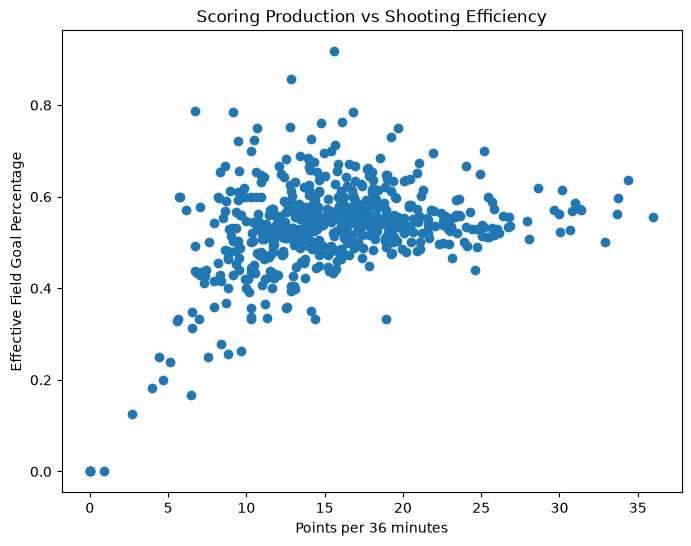

In [96]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    player_season_df["PTS_per36"],
    player_season_df["eFG%"]
)

plt.xlabel("Points per 36 minutes")
plt.ylabel("Effective Field Goal Percentage")
plt.title("Scoring Production vs Shooting Efficiency")

plt.show()

### Create dataset that does not include players with low playing time

In [97]:
scouting_df = player_season_df[
    player_season_df["MP"] >= 10
].copy()

In [98]:
scouting_df.shape

(478, 42)

In [99]:
scouting_df["MP"].describe()

count    478.000000
mean      22.510669
std        7.101743
min       10.000000
25%       16.600000
50%       22.150000
75%       28.475000
max       38.000000
Name: MP, dtype: float64

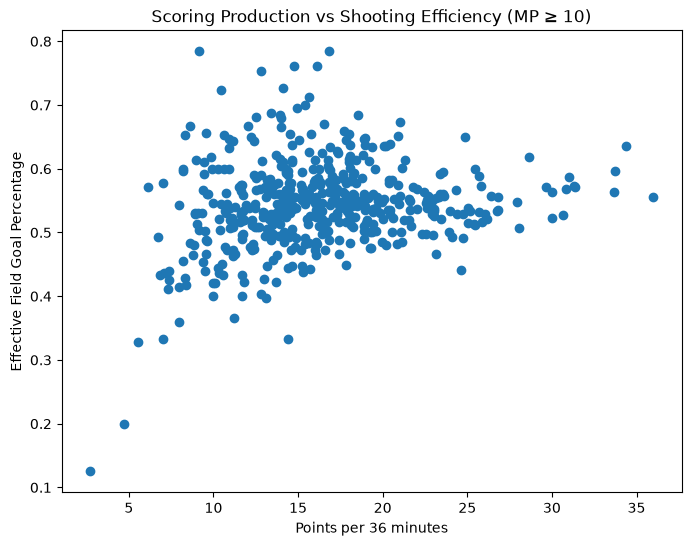

In [100]:
plt.figure(figsize=(8, 6))

plt.scatter(
    scouting_df["PTS_per36"],
    scouting_df["eFG%"]
)

plt.xlabel("Points per 36 minutes")
plt.ylabel("Effective Field Goal Percentage")
plt.title("Scoring Production vs Shooting Efficiency (MP ≥ 10)")

plt.show()

In [101]:
scouting_df[
    ["PTS_per36", "eFG%"]
].corr()

,PTS_per36,eFG%
PTS_per36,1.000000,0.202064
eFG%,0.202064,1.000000


Data suggests: Scoring production and shooting efficiency are relatively distinct dimensions among players with at least 10 MPG.

In [102]:
for threshold in [5, 10, 15, 20]:
    subset = player_season_df[player_season_df["MP"] >= threshold]
    
    correlation = subset["PTS_per36"].corr(subset["eFG%"])
    
    print(
        f"MP >= {threshold}: "
        f"n = {len(subset)}, "
        f"r = {correlation:.3f}"
    )

MP >= 5: n = 556, r = 0.295
MP >= 10: n = 478, r = 0.202
MP >= 15: n = 393, r = 0.080
MP >= 20: n = 293, r = 0.072


Correlation between points per 36, i.e. scoring production, and effective field goal percentage decreases with increased minutes played.

In [103]:
scouting_df["FGA_per36"] = (
    scouting_df["FGA"] / scouting_df["MP"]
) * 36

In [104]:
scouting_df[["Player", "G","MP", "PTS_per36", "FGA_per36", "eFG%"]
].sort_values("FGA_per36", ascending=False).head(10)

,Player,G,MP,PTS_per36,FGA_per36,eFG%
193,Tristen Newton,1.0,12.0,36.000000,27.000000,0.556
0,Luka Dončić,64.0,35.8,33.687151,22.927374,0.563
49,Ty Jerome,15.0,22.6,31.380531,22.778761,0.572
3,Jaylen Brown,71.0,34.4,30.034884,22.709302,0.522
45,LaMelo Ball,72.0,28.0,25.842857,22.242857,0.516
73,Jalen Green,32.0,25.9,24.741313,22.239382,0.491
5,Kawhi Leonard,65.0,32.1,31.289720,21.757009,0.573
11,Stephen Curry,43.0,30.9,30.990291,21.669903,0.587
6,Donovan Mitchell,70.0,33.5,29.982090,21.492537,0.563
37,Shaedon Sharpe,50.0,29.4,25.469388,21.306122,0.511


In [105]:
scouting_df[
    ["FGA_per36", "PTS_per36"]
].corr()

,FGA_per36,PTS_per36
FGA_per36,1.000000,0.918675
PTS_per36,0.918675,1.000000


In [106]:
scouting_df[
    ["FGA_per36", "PTS_per36"]
].describe().T

,count,mean,std,min,25%,50%,75%,max
FGA_per36,478.0,12.654932,3.687682,4.027972,9.946633,12.419302,14.911054,27.0
PTS_per36,478.0,16.209961,5.261015,2.691589,12.544029,15.670588,18.977882,36.0


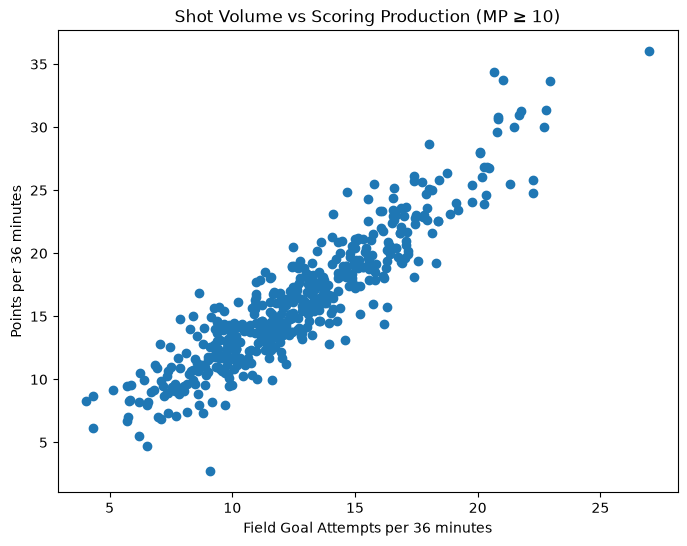

In [107]:
plt.figure(figsize=(8, 6))

plt.scatter(
    scouting_df["FGA_per36"],
    scouting_df["PTS_per36"]
)

plt.xlabel("Field Goal Attempts per 36 minutes")
plt.ylabel("Points per 36 minutes")
plt.title("Shot Volume vs Scoring Production (MP ≥ 10)")

plt.show()

Scoring production in this dataset is much more closely associated with shot volume than with shooting efficiency.

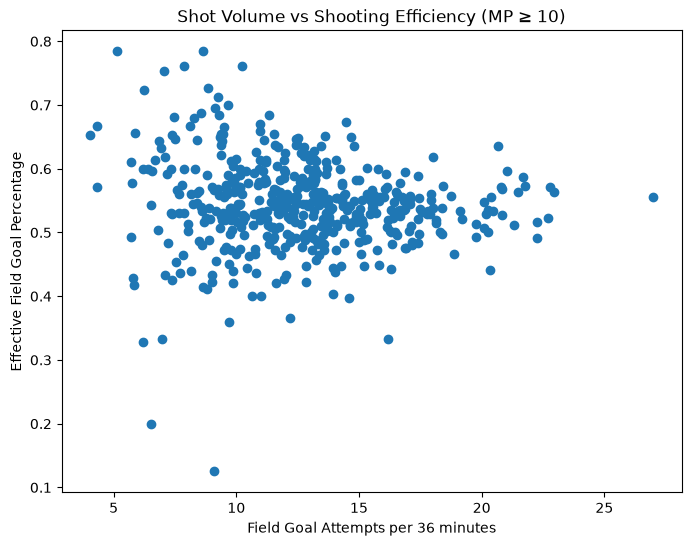

In [108]:
plt.figure(figsize=(8, 6))

plt.scatter(
    scouting_df["FGA_per36"],
    scouting_df["eFG%"]
)

plt.xlabel("Field Goal Attempts per 36 minutes")
plt.ylabel("Effective Field Goal Percentage")
plt.title("Shot Volume vs Shooting Efficiency (MP ≥ 10)")

plt.show()

In [109]:
scouting_df[
    ["FGA_per36", "eFG%"]
].corr()

,FGA_per36,eFG%
FGA_per36,1.000000,-0.108459
eFG%,-0.108459,1.000000


Within the MP ≥ 10 comparison population, FGA per 36 and eFG% show a weak negative linear association (r = -0.108).

In [110]:
print("Kernel is working")

Kernel is working


In [111]:
scouting_df[["FGA_per36", "eFG%"]].median()

FGA_per36    12.419302
eFG%          0.543000
dtype: float64

In [112]:
scouting_df["scoring_profile"] = np.select(
    [
        (scouting_df["FGA_per36"] < 12.419302) & (scouting_df["eFG%"] < 0.543),
        (scouting_df["FGA_per36"] < 12.419302) & (scouting_df["eFG%"] >= 0.543),
        (scouting_df["FGA_per36"] >= 12.419302) & (scouting_df["eFG%"] < 0.543),
        (scouting_df["FGA_per36"] >= 12.419302) & (scouting_df["eFG%"] >= 0.543)
    ],
    [
        "Lower volume / Lower efficiency",
        "Lower volume / Higher efficiency",
        "Higher volume / Lower efficiency",
        "Higher volume / Higher efficiency"
    ],
    default="Unclassified"
)

In [113]:
scouting_df["scoring_profile"].value_counts()

scoring_profile
Lower volume / Higher efficiency     126
Higher volume / Lower efficiency     125
Higher volume / Higher efficiency    114
Lower volume / Lower efficiency      113
Name: count, dtype: int64

In [114]:
median_fga36 = scouting_df["FGA_per36"].median()
median_efg = scouting_df["eFG%"].median()

print("Median FGA/36:", median_fga36)
print("Median eFG%:", median_efg)

Median FGA/36: 12.419302325581397
Median eFG%: 0.543


In [115]:
scouting_df["scoring_profile"] = np.select(
    [
        (scouting_df["FGA_per36"] < median_fga36) & (scouting_df["eFG%"] < median_efg),
        (scouting_df["FGA_per36"] < median_fga36) & (scouting_df["eFG%"] >= median_efg),
        (scouting_df["FGA_per36"] >= median_fga36) & (scouting_df["eFG%"] < median_efg),
        (scouting_df["FGA_per36"] >= median_fga36) & (scouting_df["eFG%"] >= median_efg)
    ],
    [
        "Lower volume / Lower efficiency",
        "Lower volume / Higher efficiency",
        "Higher volume / Lower efficiency",
        "Higher volume / Higher efficiency"
    ],
    default="Unclassified"
)

In [116]:
scouting_df["scoring_profile"].value_counts()

scoring_profile
Lower volume / Higher efficiency     126
Higher volume / Lower efficiency     125
Higher volume / Higher efficiency    114
Lower volume / Lower efficiency      113
Name: count, dtype: int64

In [117]:
scouting_df["scoring_profile"].isna().sum()

np.int64(0)

In [118]:
profile_summary = scouting_df.groupby("scoring_profile")[
    ["PTS_per36", "3PA_rate", "AST_per36", "MP"]
].median()

profile_summary

,PTS_per36,3PA_rate,AST_per36,MP
scoring_profile,,,,
Higher volume / Higher efficiency,19.286442,0.439424,3.308597,26.75
Higher volume / Lower efficiency,18.868966,0.401869,4.476684,25.80
Lower volume / Higher efficiency,13.965893,0.441591,2.420248,20.50
Lower volume / Lower efficiency,11.639098,0.461538,3.036145,17.90


In [119]:
profile_summary_2 = scouting_df.groupby("scoring_profile")[
    ["TRB_per36", "AST_per36", "STL_per36", "BLK_per36", "FTA_rate"]
].median()

profile_summary_2

,TRB_per36,AST_per36,STL_per36,BLK_per36,FTA_rate
scoring_profile,,,,,
Higher volume / Higher efficiency,5.757937,3.308597,1.174985,0.485513,0.246160
Higher volume / Lower efficiency,5.478261,4.476684,1.227273,0.448133,0.250000
Lower volume / Higher efficiency,6.898074,2.420248,1.183380,0.720288,0.250000
Lower volume / Lower efficiency,5.538462,3.036145,1.375796,0.592593,0.220339


In [123]:
position_profile = pd.crosstab(
    scouting_df["scoring_profile"],
    scouting_df["Pos"],
    normalize="index"
) * 100

position_profile.round(1)

Pos,C,PF,PG,SF,SG
scoring_profile,,,,,
Higher volume / Higher efficiency,18.4,18.4,15.8,19.3,28.1
Higher volume / Lower efficiency,7.2,16.0,33.6,21.6,21.6
Lower volume / Higher efficiency,34.1,19.8,4.0,15.1,27.0
Lower volume / Lower efficiency,11.5,21.2,18.6,15.0,33.6


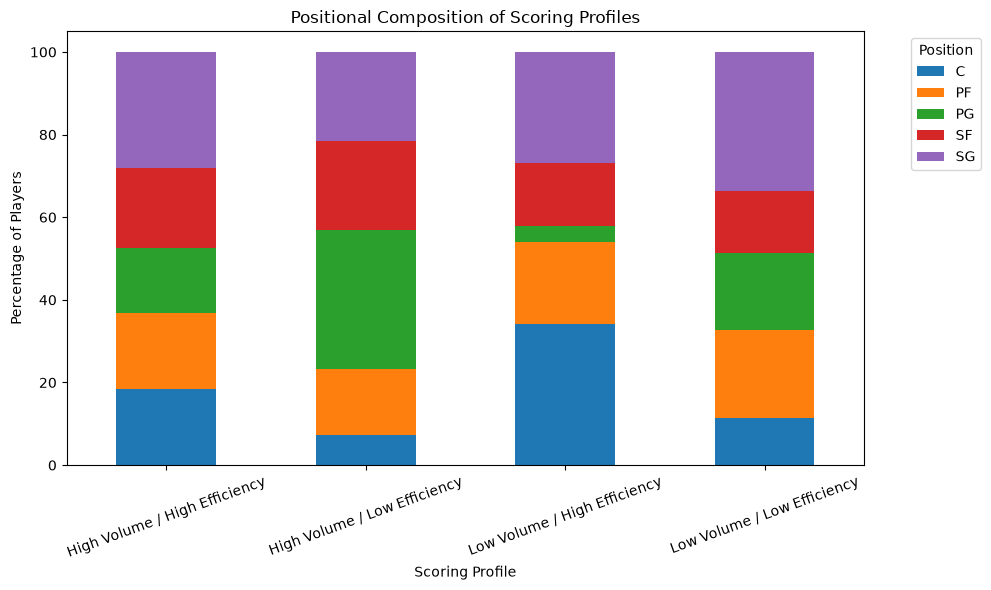

In [124]:
import matplotlib.pyplot as plt

position_profile_plot = position_profile.rename(
    index={
        "Higher volume / Higher efficiency": "High Volume / High Efficiency",
        "Higher volume / Lower efficiency": "High Volume / Low Efficiency",
        "Lower volume / Higher efficiency": "Low Volume / High Efficiency",
        "Lower volume / Lower efficiency": "Low Volume / Low Efficiency"
    }
)

position_profile_plot.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.xlabel("Scoring Profile")
plt.ylabel("Percentage of Players")
plt.title("Positional Composition of Scoring Profiles")
plt.legend(title="Position", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

# Question: Which players combine high scoring volume with high shooting efficiency, and what characteristics distinguish them from other high-volume scorers?

- Are the efficient high-volume players better passers?
- Do they get to the free-throw line more?
- Are they more effective from three?
- Do they contribute differently defensively?
- Are there particular positions that dominate either group?

In [125]:
high_volume_df = scouting_df[
    scouting_df["FGA_per36"] >= median_fga36
].copy()

In [126]:
high_volume_df["scoring_profile"].value_counts()

scoring_profile
Higher volume / Lower efficiency     125
Higher volume / Higher efficiency    114
Name: count, dtype: int64

In [127]:
high_volume_summary = high_volume_df.groupby("scoring_profile")[
    [
        "PTS_per36",
        "AST_per36",
        "TRB_per36",
        "STL_per36",
        "BLK_per36",
        "3PA_rate",
        "FTA_rate",
        "MP"
    ]
].median()

high_volume_summary

,PTS_per36,AST_per36,TRB_per36,STL_per36,BLK_per36,3PA_rate,FTA_rate,MP
scoring_profile,,,,,,,,
Higher volume / Higher efficiency,19.286442,3.308597,5.757937,1.174985,0.485513,0.439424,0.24616,26.75
Higher volume / Lower efficiency,18.868966,4.476684,5.478261,1.227273,0.448133,0.401869,0.25000,25.80


In [128]:
high_volume_efg_cutoff = high_volume_df["eFG%"].quantile(0.75)

print("75th percentile eFG%:", high_volume_efg_cutoff)

75th percentile eFG%: 0.5634999999999999


High-volume scorer: FGA/36 ≥ 12.42

High-efficiency scorer: eFG% ≥ 56.35%

In [130]:
efficient_scorers = high_volume_df[
    high_volume_df["eFG%"] >= high_volume_efg_cutoff
].copy()

In [131]:
efficient_scorers.shape

(60, 44)

In [134]:
efficient_scorers[
    [
        "Player",
        "Team",
        "Pos",
        "MP",
        "FGA_per36",
        "PTS_per36",
        "eFG%",
        "3PA_rate",
        "AST_per36",
        "FTA_rate"
    ]
].sort_values("eFG%", ascending=False).head(20)

,Player,Team,Pos,MP,FGA_per36,PTS_per36,eFG%,3PA_rate,AST_per36,FTA_rate
195,Blake Hinson,UTA,SF,20.4,14.470588,21.000000,0.674,0.682927,1.941176,0.134146
134,Cormac Ryan,MIL,SG,24.6,13.609756,20.926829,0.652,0.580645,2.487805,0.258065
50,Jalen Duren,DET,C,28.2,14.680851,24.893617,0.650,0.000000,2.553191,0.530435
262,Zach Collins,CHI,C,18.4,12.521739,18.978261,0.648,0.328125,2.934783,0.312500
231,Marvin Bagley III,2TM,PF,20.0,12.420000,18.900000,0.647,0.130435,2.520000,0.347826
110,Jarrett Allen,CLE,C,27.1,12.487085,20.457565,0.639,0.021277,2.391144,0.500000
350,Paul Reed,DET,C,13.9,13.467626,20.201439,0.636,0.115385,3.107914,0.326923
8,Giannis Antetokounmpo,MIL,PF,28.9,20.678201,34.380623,0.636,0.078313,6.726644,0.596386
294,Payton Sandfort,OKC,SF,15.8,14.810127,20.050633,0.635,0.661538,0.000000,0.153846
256,Olivier-Maxence Prosper,MEM,PF,18.6,12.774194,19.354839,0.634,0.424242,1.935484,0.333333


In [135]:
established_efficient_scorers = efficient_scorers[
    efficient_scorers["MP"] >= 20
].copy()

In [136]:
established_efficient_scorers[
    [
        "Player",
        "Team",
        "Pos",
        "MP",
        "FGA_per36",
        "PTS_per36",
        "eFG%",
        "3PA_rate",
        "AST_per36",
        "FTA_rate"
    ]
].sort_values(
    ["eFG%", "PTS_per36"],
    ascending=False
)

,Player,Team,Pos,MP,FGA_per36,PTS_per36,eFG%,3PA_rate,AST_per36,FTA_rate
195,Blake Hinson,UTA,SF,20.4,14.470588,21.000000,0.674,0.682927,1.941176,0.134146
134,Cormac Ryan,MIL,SG,24.6,13.609756,20.926829,0.652,0.580645,2.487805,0.258065
50,Jalen Duren,DET,C,28.2,14.680851,24.893617,0.650,0.000000,2.553191,0.530435
231,Marvin Bagley III,2TM,PF,20.0,12.420000,18.900000,0.647,0.130435,2.520000,0.347826
110,Jarrett Allen,CLE,C,27.1,12.487085,20.457565,0.639,0.021277,2.391144,0.500000
8,Giannis Antetokounmpo,MIL,PF,28.9,20.678201,34.380623,0.636,0.078313,6.726644,0.596386
171,Sam Merrill,CLE,SG,26.5,12.633962,17.388679,0.624,0.774194,3.260377,0.139785
215,Isaiah Joe,OKC,SG,21.2,12.905660,18.849057,0.622,0.789474,2.207547,0.223684
153,John Collins,LAC,PF,27.1,12.752768,18.066421,0.620,0.333333,1.328413,0.229167
7,Nikola Jokić,DEN,C,34.8,18.000000,28.655172,0.618,0.258621,11.068966,0.425287


Tightened criteria to: MP ≥ 20


In [137]:
established_efficient_scorers.shape

(45, 44)

In [138]:
established_efficient_scorers["Pos"].value_counts()

Pos
SG    12
C     10
PF    10
SF     8
PG     5
Name: count, dtype: int64

In [140]:
established_efficient_scorers[
    [
        "Player",
        "Team",
        "Pos",
        "MP",
        "FGA_per36",
        "PTS_per36",
        "eFG%",
        "3PA_rate",
        "AST_per36",
        "FTA_rate"
    ]
].sort_values("PTS_per36", ascending=False).head(15)

,Player,Team,Pos,MP,FGA_per36,PTS_per36,eFG%,3PA_rate,AST_per36,FTA_rate
8,Giannis Antetokounmpo,MIL,PF,28.9,20.678201,34.380623,0.636,0.078313,6.726644,0.596386
1,Shai Gilgeous-Alexander,OKC,PG,33.2,21.036145,33.722892,0.597,0.226804,7.156627,0.463918
49,Ty Jerome,MEM,SG,22.6,22.778761,31.380531,0.572,0.468531,9.079646,0.258741
5,Kawhi Leonard,LAC,SF,32.1,21.757009,31.289720,0.573,0.350515,4.037383,0.329897
11,Stephen Curry,GSW,PG,30.9,21.669903,30.990291,0.587,0.607527,5.475728,0.274194
16,Victor Wembanyama,SAS,C,29.2,20.835616,30.821918,0.569,0.325444,3.821918,0.414201
2,Anthony Edwards,MIN,SG,35.0,20.777143,29.622857,0.572,0.415842,3.805714,0.356436
7,Nikola Jokić,DEN,C,34.8,18.000000,28.655172,0.618,0.258621,11.068966,0.425287
15,Jamal Murray,DEN,PG,35.4,18.406780,25.830508,0.573,0.414365,7.220339,0.287293
14,Kevin Durant,HOU,SF,36.4,17.406593,25.714286,0.588,0.329545,4.747253,0.340909


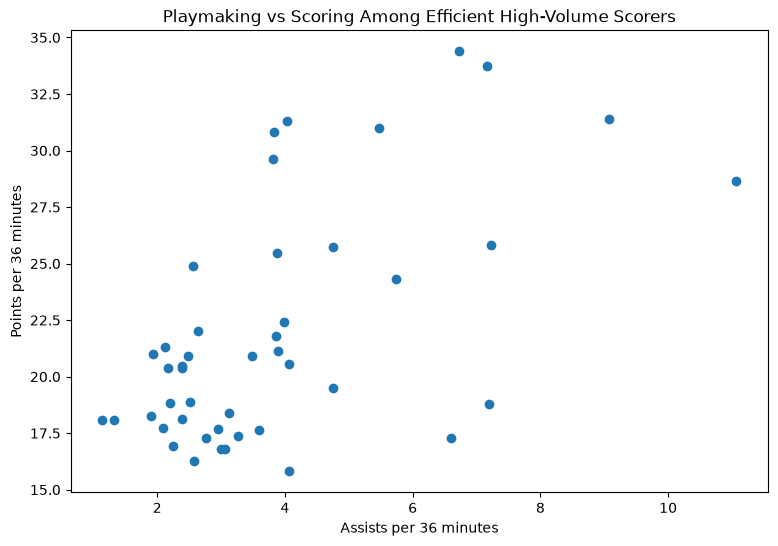

In [141]:
plt.figure(figsize=(9, 6))

plt.scatter(
    established_efficient_scorers["AST_per36"],
    established_efficient_scorers["PTS_per36"]
)

plt.xlabel("Assists per 36 minutes")
plt.ylabel("Points per 36 minutes")
plt.title("Playmaking vs Scoring Among Efficient High-Volume Scorers")

plt.show()

In [142]:
established_efficient_scorers[
    ["PTS_per36", "AST_per36"]
].median()

PTS_per36    20.457565
AST_per36     3.260377
dtype: float64

In [143]:
median_pts36 = established_efficient_scorers["PTS_per36"].median()
median_ast36 = established_efficient_scorers["AST_per36"].median()

established_efficient_scorers["offensive_archetype"] = np.select(
    [
        (established_efficient_scorers["PTS_per36"] < median_pts36) &
        (established_efficient_scorers["AST_per36"] < median_ast36),

        (established_efficient_scorers["PTS_per36"] < median_pts36) &
        (established_efficient_scorers["AST_per36"] >= median_ast36),

        (established_efficient_scorers["PTS_per36"] >= median_pts36) &
        (established_efficient_scorers["AST_per36"] < median_ast36),

        (established_efficient_scorers["PTS_per36"] >= median_pts36) &
        (established_efficient_scorers["AST_per36"] >= median_ast36)
    ],
    [
        "Lower scoring / Lower creation",
        "Lower scoring / Higher creation",
        "Higher scoring / Lower creation",
        "Higher scoring / Higher creation"
    ],
    default="Unclassified"
)

In [144]:
established_efficient_scorers["offensive_archetype"].value_counts()

offensive_archetype
Higher scoring / Higher creation    17
Lower scoring / Lower creation      16
Higher scoring / Lower creation      6
Lower scoring / Higher creation      6
Name: count, dtype: int64

In [145]:
established_efficient_scorers[
    established_efficient_scorers["offensive_archetype"] ==
    "Higher scoring / Higher creation"
][
    [
        "Player",
        "Team",
        "Pos",
        "MP",
        "PTS_per36",
        "AST_per36",
        "eFG%",
        "3PA_rate",
        "FTA_rate"
    ]
].sort_values("PTS_per36", ascending=False)

,Player,Team,Pos,MP,PTS_per36,AST_per36,eFG%,3PA_rate,FTA_rate
8,Giannis Antetokounmpo,MIL,PF,28.9,34.380623,6.726644,0.636,0.078313,0.596386
1,Shai Gilgeous-Alexander,OKC,PG,33.2,33.722892,7.156627,0.597,0.226804,0.463918
49,Ty Jerome,MEM,SG,22.6,31.380531,9.079646,0.572,0.468531,0.258741
5,Kawhi Leonard,LAC,SF,32.1,31.289720,4.037383,0.573,0.350515,0.329897
11,Stephen Curry,GSW,PG,30.9,30.990291,5.475728,0.587,0.607527,0.274194
16,Victor Wembanyama,SAS,C,29.2,30.821918,3.821918,0.569,0.325444,0.414201
2,Anthony Edwards,MIN,SG,35.0,29.622857,3.805714,0.572,0.415842,0.356436
7,Nikola Jokić,DEN,C,34.8,28.655172,11.068966,0.618,0.258621,0.425287
15,Jamal Murray,DEN,PG,35.4,25.830508,7.220339,0.573,0.414365,0.287293
14,Kevin Durant,HOU,SF,36.4,25.714286,4.747253,0.588,0.329545,0.340909


- high-volume scorers
- unusually efficient
- established in their rotation
- above the candidate-pool median in scoring
- above the candidate-pool median in playmaking

In [146]:
archetype_summary = established_efficient_scorers.groupby(
    "offensive_archetype"
)[
    [
        "PTS_per36",
        "AST_per36",
        "eFG%",
        "3PA_rate",
        "FTA_rate",
        "TRB_per36",
        "STL_per36",
        "BLK_per36"
    ]
].median()

archetype_summary

,PTS_per36,AST_per36,eFG%,3PA_rate,FTA_rate,TRB_per36,STL_per36,BLK_per36
offensive_archetype,,,,,,,,
Higher scoring / Higher creation,25.830508,4.062696,0.5740,0.396396,0.348485,5.780282,1.232877,0.538922
Higher scoring / Lower creation,21.150519,2.439474,0.6445,0.387010,0.310448,7.660900,0.911912,0.730150
Lower scoring / Higher creation,17.520146,4.404114,0.5785,0.442087,0.213602,4.327124,1.351581,0.376020
Lower scoring / Lower creation,18.073934,2.382854,0.5875,0.454765,0.226425,7.547692,0.998835,0.818199


In [147]:
established_efficient_scorers["offensive_archetype"].value_counts()

offensive_archetype
Higher scoring / Higher creation    17
Lower scoring / Lower creation      16
Higher scoring / Lower creation      6
Lower scoring / Higher creation      6
Name: count, dtype: int64

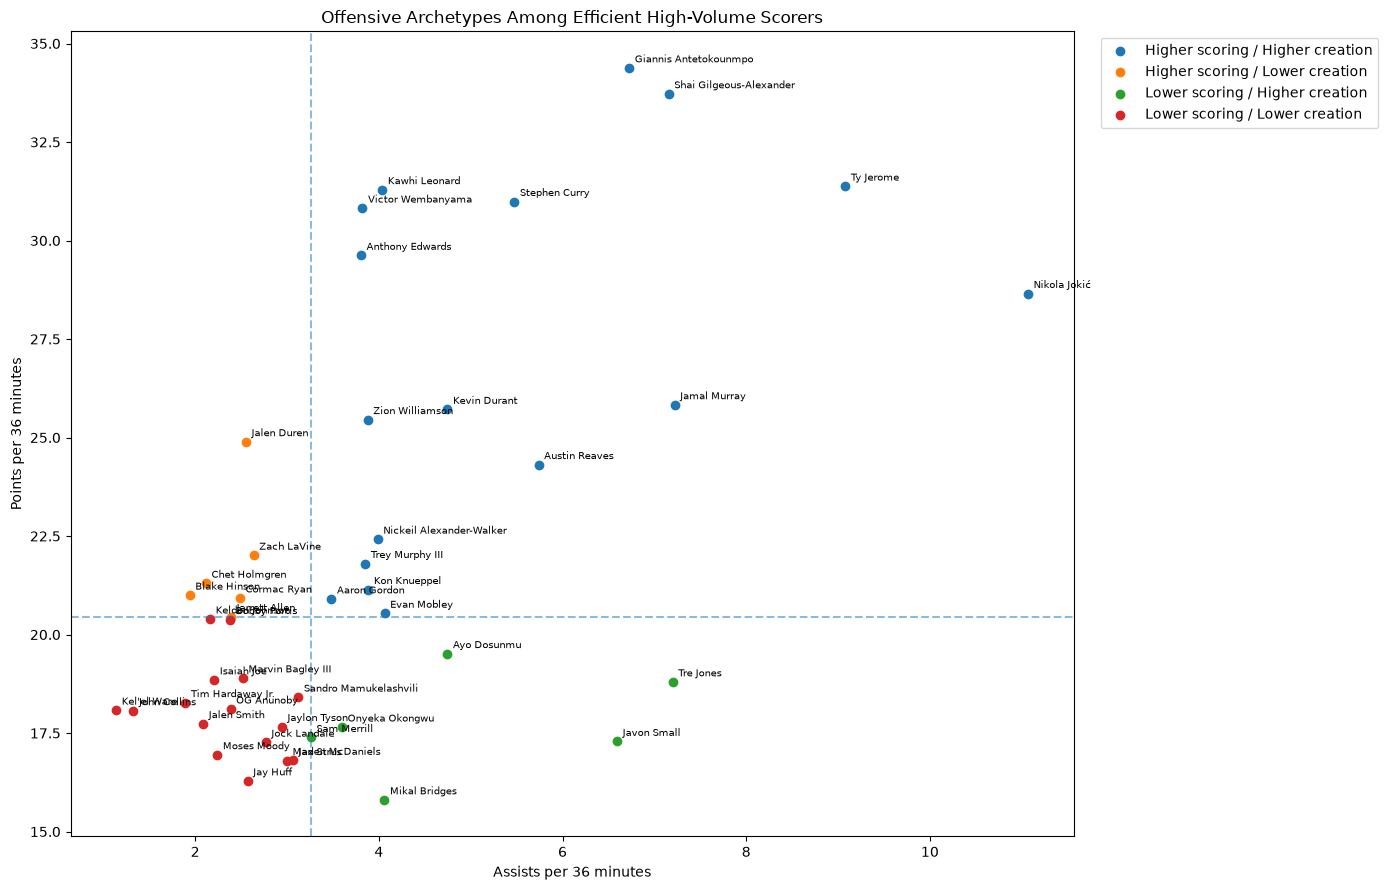

In [149]:
plt.figure(figsize=(14, 9))

for archetype, group in established_efficient_scorers.groupby(
    "offensive_archetype"
):
    plt.scatter(
        group["AST_per36"],
        group["PTS_per36"],
        label=archetype
    )

# Label every player
for _, row in established_efficient_scorers.iterrows():
    plt.annotate(
        row["Player"],
        (row["AST_per36"], row["PTS_per36"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=7
    )

# Median lines
plt.axvline(
    median_ast36,
    linestyle="--",
    alpha=0.5
)

plt.axhline(
    median_pts36,
    linestyle="--",
    alpha=0.5
)

plt.xlabel("Assists per 36 minutes")
plt.ylabel("Points per 36 minutes")
plt.title("Offensive Archetypes Among Efficient High-Volume Scorers")

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()